In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

df = pd.read_excel("data.xlsx")
arr = df.to_numpy()
students_traj = arr[:, np.r_[0:3, 4:37]]
final_mark = arr[:, 3]

In [53]:
def marked_data(studs, f_mark, t):
    kr_marks = studs[:, :3]
    tests = studs[:, 3:19]
    attendance = studs[:, 19:36]

    kr_marks_t = kr_marks[:, :t//5]/5
    tests_t = tests[:, :t]
    attendance_t = attendance[:, :t]

    if t < 15:
        category = kr_marks[:, t//5]
    else:
        category = f_mark

    X, y = np.hstack((kr_marks_t, tests_t, attendance_t)), category
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [54]:
def f_names(t):
    controls = t//5
    tests = t if t <= 16 else 16
    absence = t
    names = []
    
    names.extend([f'control_grade_{i}' for i in range(1, controls+1)])
    names.extend([f'test_score_{i}' for i in range(1, tests+1)])
    names.extend([f'absence_share_{i}' for i in range(1, absence+1)])

    return names

In [55]:
T = 12
X_train, X_test, y_train, y_test = marked_data(students_traj, final_mark, t=T)

# Логистическая регрессия

In [56]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, C=0.1))
])

st_train = time.perf_counter()
logreg.fit(X_train, y_train)
en_train = time.perf_counter()

st_pred = time.perf_counter()
y_pred = logreg.predict(X_test)
en_pred = time.perf_counter()

print('Точность Логистической регресси:', accuracy_score(y_test, y_pred))
print('Время обучения:', en_train-st_train)
print('Время предсказания:', en_pred-st_pred)

Точность Логистической регресси: 0.6558704453441295
Время обучения: 0.0328190999571234
Время предсказания: 0.0008920000400394201


# KNN

In [57]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=40, weights="uniform", metric="euclidean"))
])

st_train = time.perf_counter()
knn.fit(X_train, y_train)
en_train = time.perf_counter()

st_pred = time.perf_counter()
y_pred = knn.predict(X_test)
en_pred = time.perf_counter()

print("Точность KNN:", accuracy_score(y_test, y_pred))
print('Время обучения:', en_train-st_train)
print('Время предсказания:', en_pred-st_pred)

Точность KNN: 0.6538461538461539
Время обучения: 0.003401799942366779
Время предсказания: 0.014575300039723516


# Дерево решений

In [58]:
tree = DecisionTreeClassifier(criterion="gini", max_depth = 4, min_samples_leaf = 6, min_samples_split=3)

st_train = time.perf_counter()
tree.fit(X_train, y_train)
en_train = time.perf_counter()

st_pred = time.perf_counter()
y_pred = tree.predict(X_test)
en_pred = time.perf_counter()


print("Точность Дерева Решений:", accuracy_score(y_test, y_pred))
print('Время обучения:', en_train-st_train)
print('Время предсказания:', en_pred-st_pred)

Точность Дерева Решений: 0.6437246963562753
Время обучения: 0.01000240002758801
Время предсказания: 0.00046820007264614105


In [59]:
#Отрисовка дерева решений
fig, ax = plt.subplots(figsize=(240, 120))
plot_tree(
    tree,
    feature_names = f_names(T),
    class_names=['0', '2', '3', '4', '5'],
    ax=ax,
    filled=True
)
fig.savefig("decision_tree.png", bbox_inches="tight")
plt.close(fig)

# Случайный лес

In [60]:
forest = RandomForestClassifier(
    criterion='gini',
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=3,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True)

st_train = time.perf_counter()
forest.fit(X_train, y_train)
en_train = time.perf_counter()

st_pred = time.perf_counter()
y_pred = forest.predict(X_test)
en_pred = time.perf_counter()

print("Точность Случайного леса:", accuracy_score(y_test, y_pred))
print('Время обучения:', en_train-st_train)
print('Время предсказания:', en_pred-st_pred)

Точность Случайного леса: 0.6761133603238867
Время обучения: 1.3116934000281617
Время предсказания: 0.05480609997175634


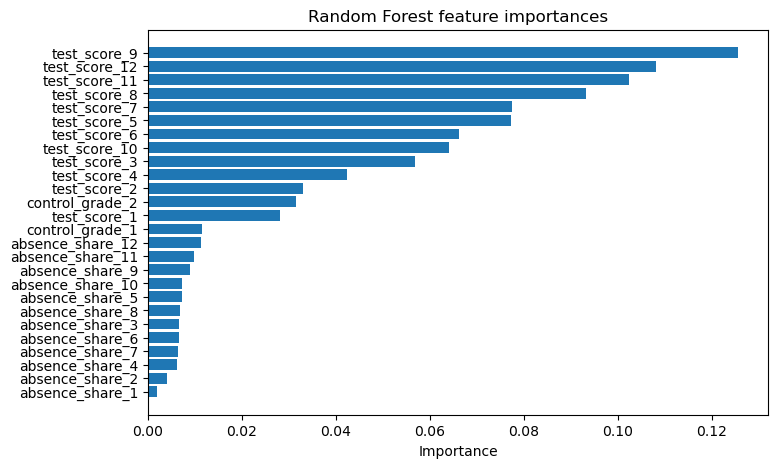

In [61]:
importances = forest.feature_importances_

feature_importance = pd.DataFrame({
    "feature": f_names(T),
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest feature importances")
plt.show()

# Градиентный бустинг

In [62]:
gboost = GradientBoostingClassifier(n_estimators=150, n_iter_no_change = 10, max_depth=2, min_samples_leaf=7, learning_rate=0.05)

st_train = time.perf_counter()
gboost.fit(X_train, y_train)
en_train = time.perf_counter()

st_pred = time.perf_counter()
y_pred = gboost.predict(X_test)
en_pred = time.perf_counter()

print("Точность Градиентного Бустинга:", accuracy_score(y_test, y_pred))
print('Время обучения:', en_train-st_train)
print('Время предсказания:', en_pred-st_pred)

Точность Градиентного Бустинга: 0.6740890688259109
Время обучения: 0.9749068000819534
Время предсказания: 0.0025485000805929303


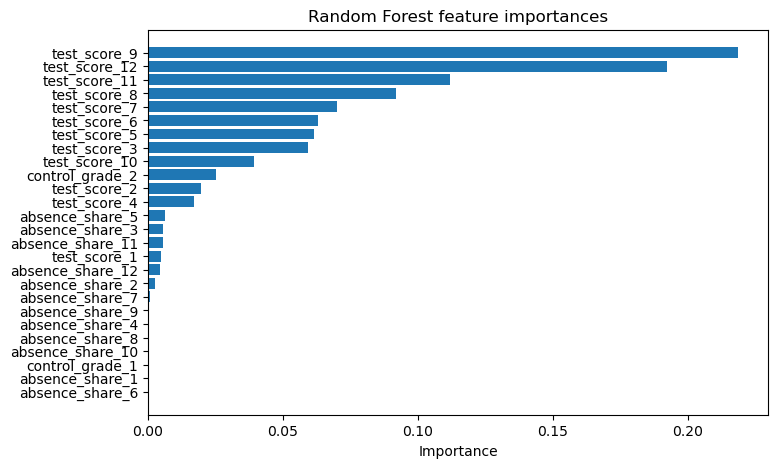

In [63]:
importances = gboost.feature_importances_

feature_importance = pd.DataFrame({
    "feature": f_names(T),
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest feature importances")
plt.show()

# Обощенный классификатор

In [64]:
voting = VotingClassifier(
    estimators=[
        ("logreg", logreg),
        ("knn", knn),
        ("tree", tree),
        ("forest", forest),
        ("gboost", gboost),
    ],
    voting='hard'
)

st_train = time.perf_counter()
voting.fit(X_train, y_train)
en_train = time.perf_counter()

st_pred = time.perf_counter()
y_pred = voting.predict(X_test)
en_pred = time.perf_counter()

print("Точность Обобщённого классификатора:", accuracy_score(y_test, y_pred))
print('Время обучения:', en_train-st_train)
print('Время предсказания:', en_pred-st_pred)

Точность Обобщённого классификатора: 0.659919028340081
Время обучения: 3.3417430999688804
Время предсказания: 0.08892959996592253


# Main

In [65]:
logreg_acc = []
knn_acc = []
tree_acc = []
forest_acc = []
gboost_acc = []
voting_acc = []

for t in tqdm(range(1, 18)):
    X_train, X_test, y_train, y_test = marked_data(students_traj, final_mark, t=t)
    
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    logreg_acc.append(accuracy_score(y_test, y_pred))

    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    knn_acc.append(accuracy_score(y_test, y_pred))

    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    tree_acc.append(accuracy_score(y_test, y_pred))

    forest.fit(X_train, y_train)
    y_pred = forest.predict(X_test)
    forest_acc.append(accuracy_score(y_test, y_pred))

    gboost.fit(X_train, y_train)
    y_pred = gboost.predict(X_test)
    gboost_acc.append(accuracy_score(y_test, y_pred))

    voting.fit(X_train, y_train)
    y_pred = voting.predict(X_test)
    voting_acc.append(accuracy_score(y_test, y_pred))

100%|██████████| 17/17 [01:26<00:00,  5.07s/it]


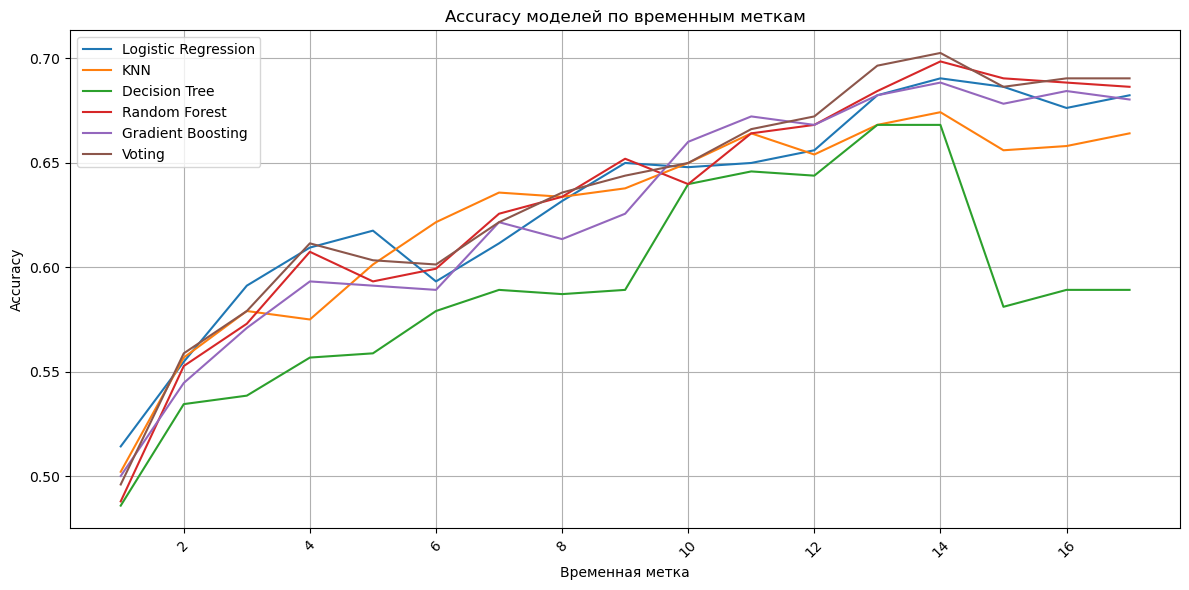

In [66]:
timestamps = list(range(1, 18))

plt.figure(figsize=(12, 6))

plt.plot(timestamps, logreg_acc, label="Logistic Regression")
plt.plot(timestamps, knn_acc, label="KNN")
plt.plot(timestamps, tree_acc, label="Decision Tree")
plt.plot(timestamps, forest_acc, label="Random Forest")
plt.plot(timestamps, gboost_acc, label="Gradient Boosting")
plt.plot(timestamps, voting_acc, label="Voting")

plt.xlabel("Временная метка")
plt.ylabel("Accuracy")
plt.title("Accuracy моделей по временным меткам")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()